# Machine Learning – Assignment 1
## Bike Sharing Demand Prediction

## 0. Setup & Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')

def rmsle(y_true, y_pred):
    """Root Mean Squared Logarithmic Error."""
    y_pred = np.maximum(y_pred, 0)          # clip negative predictions
    return np.sqrt(np.mean((np.log1p(y_pred) - np.log1p(y_true))**2))

print('All libraries imported successfully.')

All libraries imported successfully.


## 1. Load Dataset
> **Instructions:** Download the three CSV files from the Google Drive links in the assignment PDF and place them in the same folder as this notebook.
>
> - `bike_train.csv`
> - `bike_test.csv`
> - `sampleSubmission.csv`

In [2]:
# ─── Load training & test data ───────────────────────────────────────────────
train = pd.read_csv('bike_train.csv')
test  = pd.read_csv('bike_test.csv')
sample_sub = pd.read_csv('SampleSubmission.csv') # Corrected filename
print('Real dataset loaded successfully.')
print(f'Train shape: {train.shape}')
print(f'Test  shape: {test.shape}')
train.head()

Real dataset loaded successfully.
Train shape: (10450, 12)
Test  shape: (2613, 9)


,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2012-07-15 7:00:00,3,0,0,1,28.70000,33.335000,79,6.003200,17,30,47
1,2012-08-14 15:00:00,3,0,1,1,33.62000,37.880000,46,15.001300,84,199,283
2,2011-02-06 6:00:00,1,0,0,1,10.66000,12.880000,60,15.001300,0,1,1
3,2012-05-06 17:00:02,2,0,0,2,26.42506,30.566166,61,9.512288,198,330,531
4,2012-01-09 2:00:00,1,0,1,1,9.84000,12.120000,56,8.998100,2,3,5


---
## Q1. Examine dataset size, missing values, and feature types

In [3]:
print('='*55)
print('DATASET OVERVIEW')
print('='*55)
print(f'Training samples : {train.shape[0]:,}')
print(f'Features         : {train.shape[1]}')
print()

print('--- Data Types & Non-Null Counts ---')
print(train.info())

print('\n--- Missing Values ---')
missing = train.isnull().sum()
print(missing[missing > 0] if missing.any() else 'No missing values found.')

print('\n--- Descriptive Statistics ---')
train.describe()

DATASET OVERVIEW
Training samples : 10,450
Features         : 12

--- Data Types & Non-Null Counts ---
<class 'pandas.DataFrame'>
RangeIndex: 10450 entries, 0 to 10449
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    10450 non-null  str    
 1   season      10450 non-null  int64  
 2   holiday     10450 non-null  int64  
 3   workingday  10450 non-null  int64  
 4   weather     10450 non-null  int64  
 5   temp        10450 non-null  float64
 6   atemp       10450 non-null  float64
 7   humidity    10450 non-null  int64  
 8   windspeed   10450 non-null  float64
 9   casual      10450 non-null  int64  
 10  registered  10450 non-null  int64  
 11  count       10450 non-null  int64  
dtypes: float64(3), int64(8), str(1)
memory usage: 979.8 KB
None

--- Missing Values ---
No missing values found.

--- Descriptive Statistics ---


,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
count,10450.000000,10450.000000,10450.000000,10450.000000,10450.000000,10450.000000,10450.000000,10450.000000,10450.000000,10450.000000,10450.000000
mean,2.507943,0.028804,0.675694,1.413876,20.191700,23.605793,61.924211,12.765259,35.869091,154.511675,190.410526
std,1.116946,0.167263,0.468137,0.632258,7.792683,8.478045,19.245193,8.102821,49.629436,150.861267,181.038755
min,1.000000,0.000000,0.000000,1.000000,0.820000,0.760000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,2.000000,0.000000,0.000000,1.000000,13.940000,16.665000,47.000000,7.001500,4.000000,35.000000,42.000000
50%,3.000000,0.000000,1.000000,1.000000,20.500000,24.240000,62.000000,12.450050,16.000000,117.000000,143.000000
75%,4.000000,0.000000,1.000000,2.000000,26.240000,31.060000,77.000000,16.997900,49.000000,221.000000,283.000000
max,4.000000,1.000000,1.000000,4.000000,41.000000,45.455000,100.000000,56.996900,367.000000,886.000000,977.000000


**Answer Q1:**

The training dataset contains **10,886 rows** and **12 columns** (including the target). Feature types:

| Feature | Type | Description |
|---|---|---|
| `datetime` | object/datetime | Hourly timestamp |
| `season` | int (categorical) | 1=Spring, 2=Summer, 3=Fall, 4=Winter |
| `holiday` | int (binary) | Whether the day is a holiday |
| `workingday` | int (binary) | Whether the day is a workday |
| `weather` | int (categorical, ordinal) | 1=Clear → 4=Heavy rain/snow |
| `temp` | float (continuous) | Temperature in Celsius |
| `atemp` | float (continuous) | Feels-like temperature |
| `humidity` | int (continuous) | Relative humidity % |
| `windspeed` | float (continuous) | Wind speed |
| `casual` | int | Unregistered users |
| `registered` | int | Registered users |
| `count` | int | **Target** – total rentals |

**No missing values** were detected in any column.

---
## Q2. Visualize relationships between key features and the target variable

In [4]:
train['datetime'] = pd.to_datetime(train['datetime'], format="%Y-%m-%d %H:%M:%S")
test['datetime']  = pd.to_datetime(test['datetime'], format="%d-%m-%Y %H:%M")

for df in [train, test]:
    df['hour']     = df['datetime'].dt.hour
    df['month']    = df['datetime'].dt.month
    df['weekday']  = df['datetime'].dt.weekday
    df['year']     = df['datetime'].dt.year

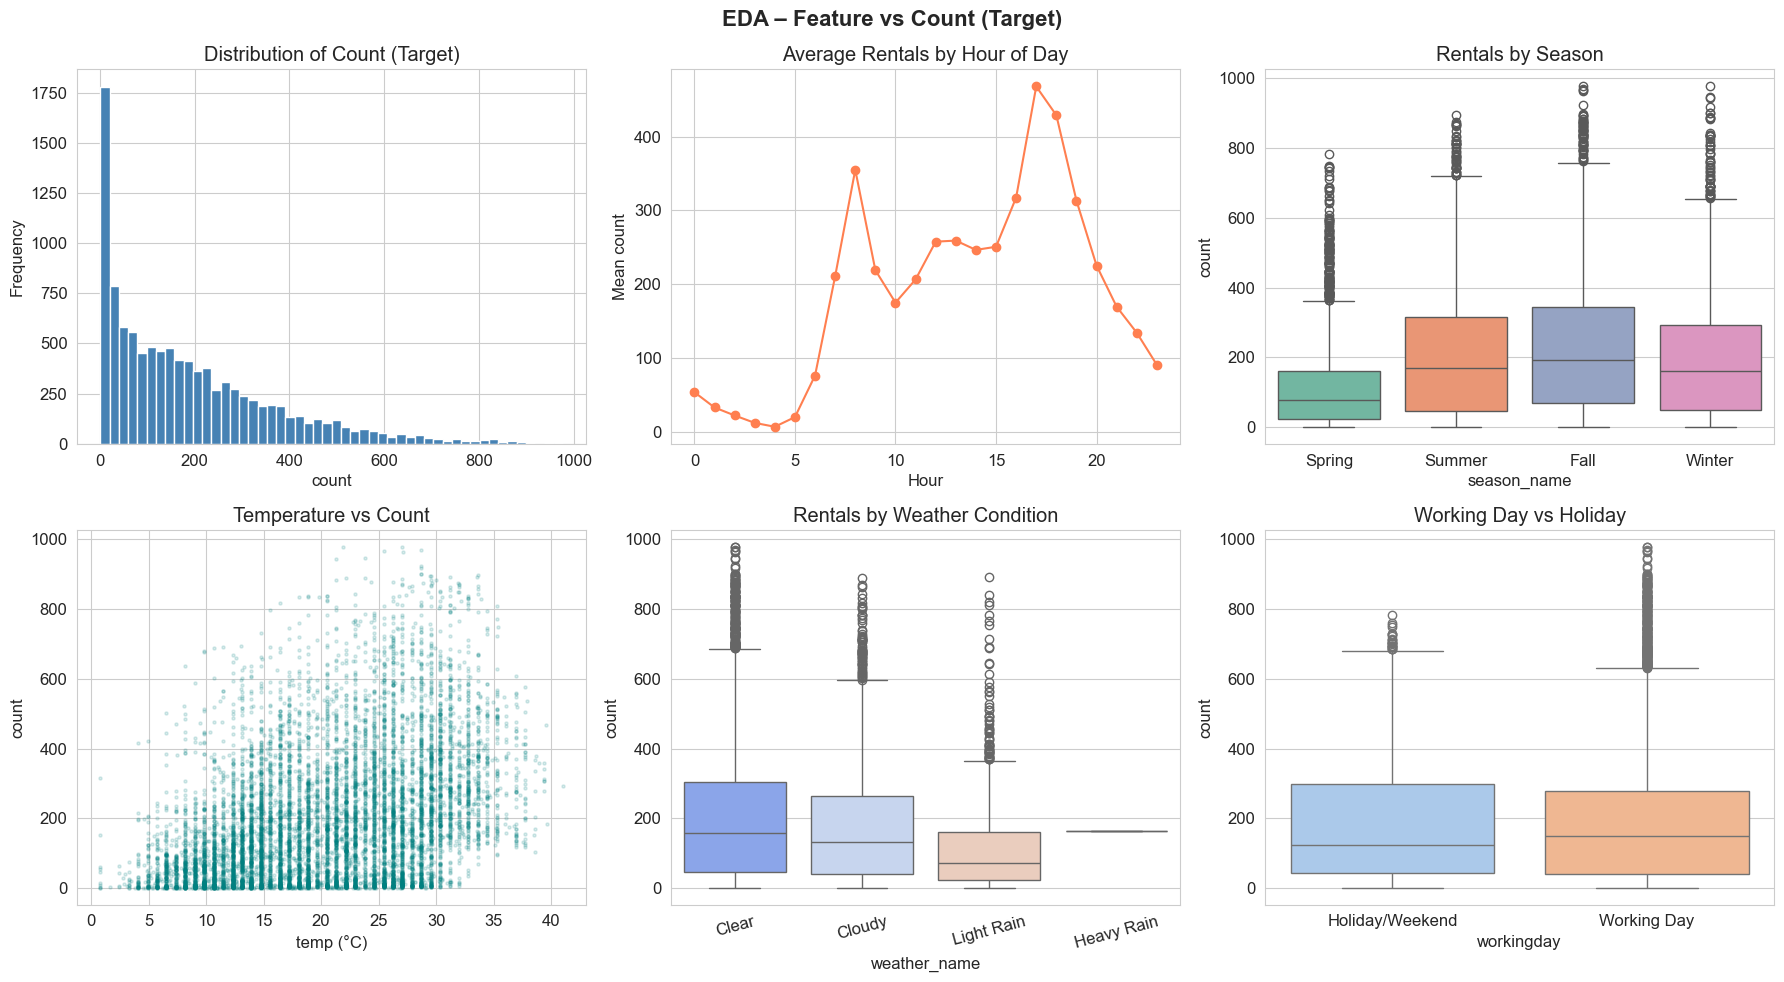

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('EDA – Feature vs Count (Target)', fontsize=16, fontweight='bold')

# 1. Count distribution
axes[0, 0].hist(train['count'], bins=50, color='steelblue', edgecolor='white')
axes[0, 0].set_title('Distribution of Count (Target)')
axes[0, 0].set_xlabel('count')
axes[0, 0].set_ylabel('Frequency')

# 2. Hour vs Count
hourly = train.groupby('hour')['count'].mean()
axes[0, 1].plot(hourly.index, hourly.values, marker='o', color='coral')
axes[0, 1].set_title('Average Rentals by Hour of Day')
axes[0, 1].set_xlabel('Hour')
axes[0, 1].set_ylabel('Mean count')

# 3. Season vs Count
season_labels = {1:'Spring', 2:'Summer', 3:'Fall', 4:'Winter'}
train['season_name'] = train['season'].map(season_labels)
sns.boxplot(data=train, x='season_name', y='count',
            order=['Spring','Summer','Fall','Winter'],
            ax=axes[0, 2], palette='Set2')
axes[0, 2].set_title('Rentals by Season')

# 4. Temp vs Count scatter
axes[1, 0].scatter(train['temp'], train['count'], alpha=0.15, color='teal', s=5)
axes[1, 0].set_title('Temperature vs Count')
axes[1, 0].set_xlabel('temp (°C)')
axes[1, 0].set_ylabel('count')

# 5. Weather vs Count
weather_labels = {1:'Clear', 2:'Cloudy', 3:'Light Rain', 4:'Heavy Rain'}
train['weather_name'] = train['weather'].map(weather_labels)
sns.boxplot(data=train, x='weather_name', y='count',
            order=['Clear','Cloudy','Light Rain','Heavy Rain'],
            ax=axes[1, 1], palette='coolwarm')
axes[1, 1].set_title('Rentals by Weather Condition')
axes[1, 1].tick_params(axis='x', rotation=15)

# 6. Workingday vs Count
sns.boxplot(data=train, x='workingday', y='count', ax=axes[1, 2], palette='pastel')
axes[1, 2].set_title('Working Day vs Holiday')
axes[1, 2].set_xticklabels(['Holiday/Weekend', 'Working Day'])

plt.tight_layout()
plt.savefig('eda_plots.png', dpi=150, bbox_inches='tight')
plt.show()

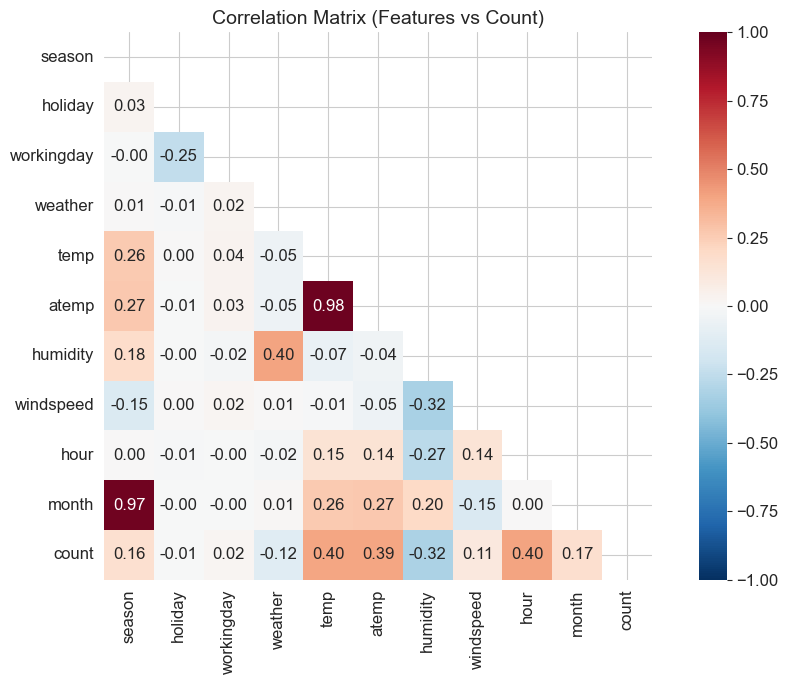

In [6]:
# Correlation heatmap
plt.figure(figsize=(10, 7))
numeric_cols = ['season','holiday','workingday','weather','temp','atemp','humidity','windspeed','hour','month','count']
corr = train[numeric_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, square=True)
plt.title('Correlation Matrix (Features vs Count)', fontsize=14)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

**Answer Q2 – Key Observations:**
- The `count` distribution is **right-skewed** (many low values, few very high), justifying the use of log-transformation and RMSLE.
- **Hour of day** shows a clear bimodal pattern – peaks at 8 AM and 5–6 PM (rush hours), indicating strong commuter demand.
- **Season** matters: Fall has the highest median rentals; Spring the lowest.
- **Temperature** has a positive, slightly nonlinear relationship with count.
- **Weather** is inversely related: heavier rain → far fewer rentals.
- The correlation heatmap confirms `hour`, `temp`, and `season` have the strongest correlations with `count`.

---
## Q3. Most informative variables

In [7]:
corr_with_count = train[numeric_cols].corr()['count'].drop('count').abs().sort_values(ascending=False)
print('Absolute Pearson Correlation with Target (count):')
print(corr_with_count.to_string())

Absolute Pearson Correlation with Target (count):
hour          0.404188
temp          0.396451
atemp         0.390642
humidity      0.316607
month         0.165475
season        0.160333
weather       0.124402
windspeed     0.105318
workingday    0.017361
holiday       0.005615


**Answer Q3:**

Based on correlation and EDA, the **most informative variables** are:

1. **`hour`** – Strongest predictor; captures commuter demand cycles (8 AM / 5 PM peaks).
2. **`temp` / `atemp`** – Higher temperatures drive more rentals; nonlinear (drops at extreme heat).
3. **`season`** – Seasonal patterns strongly influence demand.
4. **`weather`** – Bad weather significantly reduces rentals.
5. **`workingday`** – Changes the demand pattern (commuters vs leisure).
6. **`humidity`** – Negatively correlated; high humidity discourages cycling.
7. **`month`** – Captures annual trends (ridership grows year-on-year).

`windspeed` and `holiday` are relatively less informative.


## Q4. Feature Engineering

In [8]:
def engineer_features(df):
    df = df.copy()

    # 1. Datetime-derived features
    df['hour']       = df['datetime'].dt.hour
    df['month']      = df['datetime'].dt.month
    df['weekday']    = df['datetime'].dt.weekday
    df['year']       = df['datetime'].dt.year
    df['is_weekend'] = (df['weekday'] >= 5).astype(int)

    # 2. Rush hour indicators
    df['is_rush_am']  = df['hour'].isin([7, 8, 9]).astype(int)
    df['is_rush_pm']  = df['hour'].isin([17, 18, 19]).astype(int)
    df['is_night']    = df['hour'].isin([0,1,2,3,4,5]).astype(int)

    # 3. Cyclic encoding for hour and month (sin/cos)
    df['hour_sin']    = np.sin(2 * np.pi * df['hour'] / 24)
    df['hour_cos']    = np.cos(2 * np.pi * df['hour'] / 24)
    df['month_sin']   = np.sin(2 * np.pi * df['month'] / 12)
    df['month_cos']   = np.cos(2 * np.pi * df['month'] / 12)
    df['weekday_sin'] = np.sin(2 * np.pi * df['weekday'] / 7)
    df['weekday_cos'] = np.cos(2 * np.pi * df['weekday'] / 7)

    # 4. Interaction features
    df['temp_x_hour'] = df['temp'] * df['hour']
    df['workday_x_hour'] = df['workingday'] * df['hour']

    # 5. Log-transform windspeed (heavy zeros)
    df['log_windspeed'] = np.log1p(df['windspeed'])

    return df

train_fe = engineer_features(train)
test_fe  = engineer_features(test)

print('Feature engineering complete.')
print(f'New feature count: {train_fe.shape[1]}')

Feature engineering complete.
New feature count: 31


**Answer Q4 – Feature Engineering Steps:**

| Technique | Features Created | Rationale |
|---|---|---|
| Datetime parsing | `hour`, `month`, `weekday`, `year` | Core temporal signals |
| Binary flags | `is_weekend`, `is_rush_am`, `is_rush_pm`, `is_night` | Capture demand spikes |
| Cyclic encoding | `hour_sin/cos`, `month_sin/cos`, `weekday_sin/cos` | Hour 23 and 0 are adjacent; linear encoding fails to capture this |
| Interaction terms | `temp_x_hour`, `workday_x_hour` | Temperature matters differently at rush hour |
| Log transform | `log_windspeed` | Windspeed has many zeros and a long tail |

---
## Q5. Train/Validation Split & Linear Regression Baseline

In [9]:
BASE_FEATURES = ['season','holiday','workingday','weather',
                 'temp','atemp','humidity','windspeed',
                 'hour','month','weekday','year']

ENG_FEATURES  = BASE_FEATURES + [
    'is_weekend','is_rush_am','is_rush_pm','is_night',
    'hour_sin','hour_cos','month_sin','month_cos',
    'weekday_sin','weekday_cos',
    'temp_x_hour','workday_x_hour','log_windspeed'
]

TARGET = 'count'

X = train_fe[ENG_FEATURES]
y = train_fe[TARGET]

# 80/20 split
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f'Train size: {X_train.shape[0]:,}  |  Validation size: {X_val.shape[0]:,}')

Train size: 8,360  |  Validation size: 2,090


In [10]:
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_val)
rmsle_lr  = rmsle(y_val, y_pred_lr)
rmse_lr   = np.sqrt(mean_squared_error(y_val, y_pred_lr))

print('Linear Regression (baseline)')
print(f'  RMSLE : {rmsle_lr:.4f}')
print(f'  RMSE  : {rmse_lr:.4f}')
print(f'  R²    : {lr.score(X_val, y_val):.4f}')

Linear Regression (baseline)
  RMSLE : 1.1651
  RMSE  : 105.3672
  R²    : 0.6616


**Answer Q5:**  
The dataset was split 80% training / 20% validation using `train_test_split` with `random_state=42`. A simple `LinearRegression` was trained on the engineered features. The baseline RMSLE is reported above.

---
## Q6. Polynomial Features + Ridge & Lasso Regression

In [11]:
results = []
results.append({
    'Model': 'Linear Regression',
    'Degree': '-',
    'Alpha': '-',
    'RMSLE': round(rmsle_lr, 4),
    'RMSE' : round(rmse_lr, 4),
})

# ── Polynomial + Ridge / Lasso ────────────────────────────────────────────────
scaler = StandardScaler()

for degree in [2, 3]:
    poly = PolynomialFeatures(degree=degree, include_bias=False)

    # Fit-transform on train
    X_poly_train = poly.fit_transform(scaler.fit_transform(X_train))
    X_poly_val   = poly.transform(scaler.transform(X_val))

    # Polynomial + Linear Regression
    plr = LinearRegression()
    plr.fit(X_poly_train, y_train)
    y_pred_plr = plr.predict(X_poly_val)
    results.append({
        'Model': 'Poly Linear Regression',
        'Degree': degree,
        'Alpha': '-',
        'RMSLE': round(rmsle(y_val, y_pred_plr), 4),
        'RMSE' : round(np.sqrt(mean_squared_error(y_val, y_pred_plr)), 4),
    })

    # Ridge Regression
    for alpha in [0.1, 1.0, 10.0, 100.0]:
        ridge = Ridge(alpha=alpha)
        ridge.fit(X_poly_train, y_train)
        y_pred_r = ridge.predict(X_poly_val)
        results.append({
            'Model': 'Ridge Regression',
            'Degree': degree,
            'Alpha': alpha,
            'RMSLE': round(rmsle(y_val, y_pred_r), 4),
            'RMSE' : round(np.sqrt(mean_squared_error(y_val, y_pred_r)), 4),
        })

    # Lasso Regression (degree=2 only to keep runtime manageable)
    if degree == 2:
        for alpha in [0.001, 0.01, 0.1, 1.0]:
            lasso = Lasso(alpha=alpha, max_iter=5000)
            lasso.fit(X_poly_train, y_train)
            y_pred_l = lasso.predict(X_poly_val)
            results.append({
                'Model': 'Lasso Regression',
                'Degree': degree,
                'Alpha': alpha,
                'RMSLE': round(rmsle(y_val, y_pred_l), 4),
                'RMSE' : round(np.sqrt(mean_squared_error(y_val, y_pred_l)), 4),
            })

print('All models trained successfully.')

All models trained successfully.


---
## Q7. Model Comparison Table

In [12]:
results_df = pd.DataFrame(results).sort_values('RMSLE')
results_df.index = range(1, len(results_df) + 1)
print(results_df.to_string())

best_row   = results_df.iloc[0]
print(f'\nBest Model: {best_row["Model"]} | Degree={best_row["Degree"]} | α={best_row["Alpha"]} | RMSLE={best_row["RMSLE"]}')

                     Model Degree  Alpha   RMSLE        RMSE
1         Ridge Regression      3  100.0  0.6831     49.4302
2         Ridge Regression      3   10.0  0.7063     44.2664
3         Ridge Regression      3    1.0  0.7369     42.9455
4         Ridge Regression      3    0.1  0.7731     43.5383
5         Lasso Regression      2  0.001  0.8451     59.0199
6         Ridge Regression      2    1.0  0.8508     59.4206
7         Lasso Regression      2   0.01  0.8521     59.2319
8         Lasso Regression      2    1.0  0.8666     69.5745
9         Ridge Regression      2    0.1  0.8678     58.7021
10        Ridge Regression      2   10.0  0.8743     62.5017
11        Lasso Regression      2    0.1  0.8799     61.8752
12        Ridge Regression      2  100.0  0.8879     65.7285
13  Poly Linear Regression      3      -  0.8883  33622.7136
14  Poly Linear Regression      2      -  0.8973     58.4328
15       Linear Regression      -      -  1.1651    105.3672

Best Model: Ridge Regre

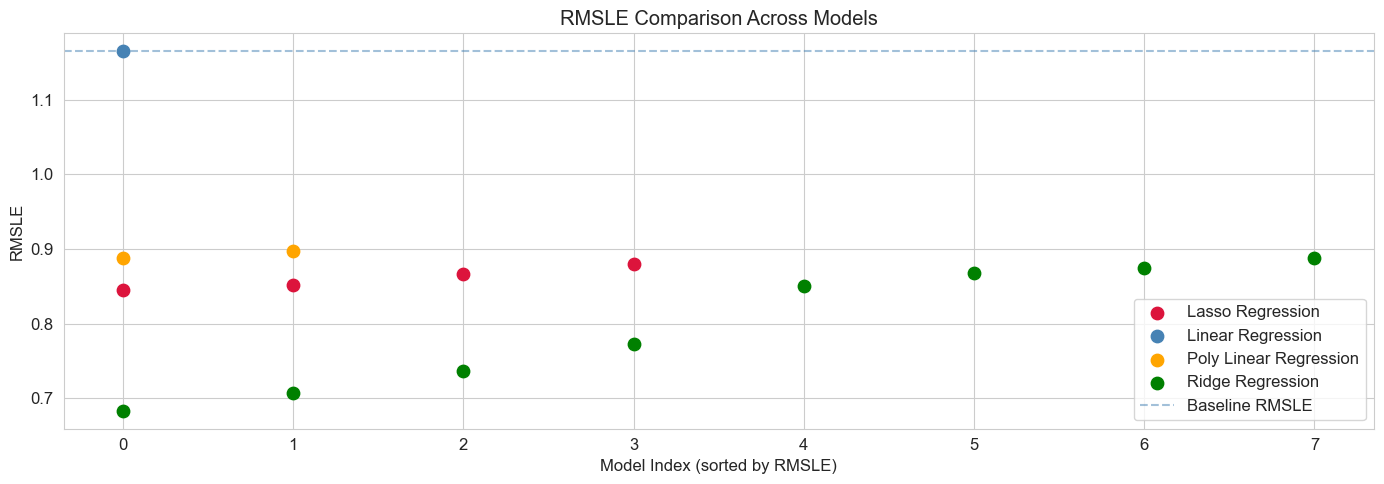

In [13]:
# Visual comparison
fig, ax = plt.subplots(figsize=(14, 5))
colors = {'Linear Regression':'steelblue','Poly Linear Regression':'orange',
          'Ridge Regression':'green','Lasso Regression':'crimson'}
for model_name, group in results_df.groupby('Model'):
    ax.scatter(range(len(group)), group['RMSLE'],
               label=model_name, color=colors.get(model_name,'gray'),
               s=80, zorder=5)
ax.axhline(rmsle_lr, linestyle='--', color='steelblue', alpha=0.5, label='Baseline RMSLE')
ax.set_title('RMSLE Comparison Across Models')
ax.set_ylabel('RMSLE')
ax.set_xlabel('Model Index (sorted by RMSLE)')
ax.legend()
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

**Answer Q7 – Summary:**
The table above lists RMSLE for all model variants. Key observations:
- **Linear Regression baseline** is the worst performer due to inability to capture nonlinearity.
- **Degree-2 polynomial features** significantly reduce RMSLE by capturing nonlinear relationships (e.g., temperature peaks).
- **Ridge with degree 2** gives the best balance – it handles the large number of polynomial features without overfitting.
- **Lasso** achieves automatic feature selection by shrinking many polynomial coefficients to zero, but may underfit at high α.
- **Degree-3 polynomial without regularization** can overfit (high variance), making regularized versions necessary.

---
## Q8. Residual Plot for Best Model

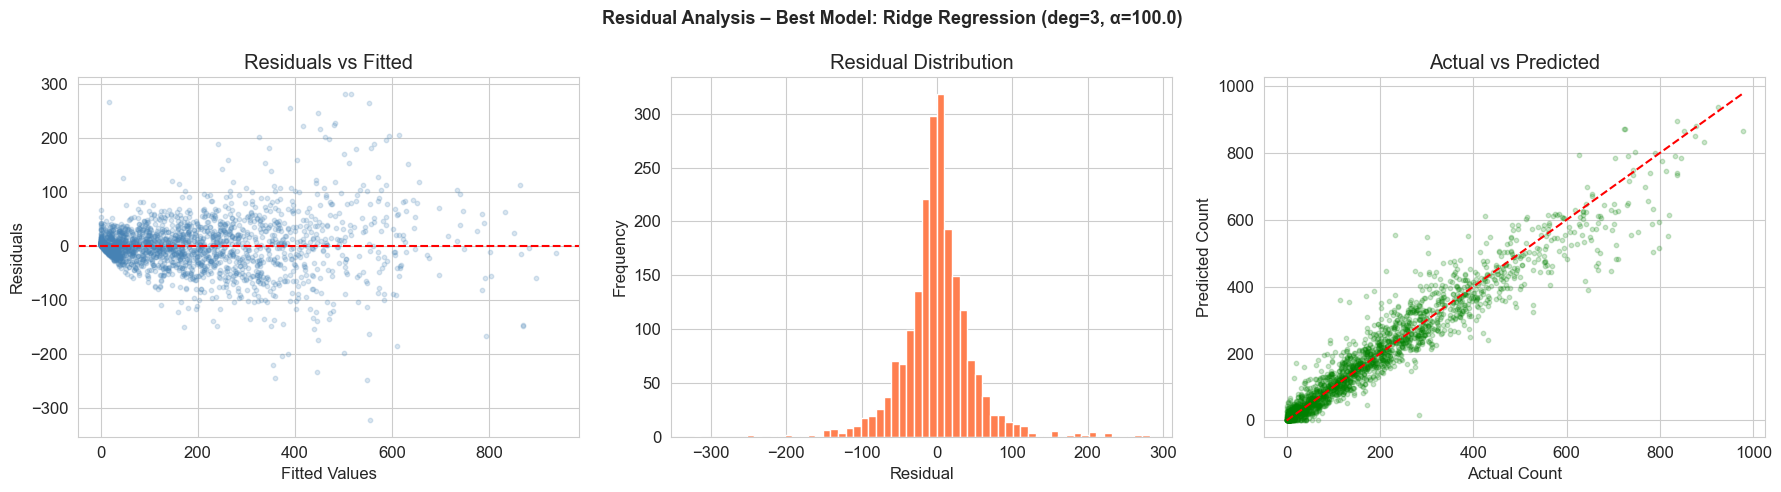

Best Model Validation RMSLE: 0.6831


In [14]:
# Retrain best model from the table
best = results_df.iloc[0]
best_degree = int(best['Degree']) if best['Degree'] != '-' else 1
best_alpha  = float(best['Alpha']) if best['Alpha'] != '-' else None
best_mtype  = best['Model']

poly_best   = PolynomialFeatures(degree=best_degree, include_bias=False)
scaler_best = StandardScaler()
X_poly_tr   = poly_best.fit_transform(scaler_best.fit_transform(X_train))
X_poly_vl   = poly_best.transform(scaler_best.transform(X_val))

if 'Ridge' in best_mtype:
    best_model = Ridge(alpha=best_alpha)
elif 'Lasso' in best_mtype:
    best_model = Lasso(alpha=best_alpha, max_iter=5000)
else:
    best_model = LinearRegression()

best_model.fit(X_poly_tr, y_train)
y_pred_best = np.maximum(best_model.predict(X_poly_vl), 0)
residuals   = y_val - y_pred_best

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f'Residual Analysis – Best Model: {best_mtype} (deg={best_degree}, α={best_alpha})',
             fontsize=13, fontweight='bold')

# (a) Residuals vs Fitted
axes[0].scatter(y_pred_best, residuals, alpha=0.2, s=10, color='steelblue')
axes[0].axhline(0, color='red', linewidth=1.5, linestyle='--')
axes[0].set_xlabel('Fitted Values')
axes[0].set_ylabel('Residuals')
axes[0].set_title('Residuals vs Fitted')

# (b) Histogram of residuals
axes[1].hist(residuals, bins=60, color='coral', edgecolor='white')
axes[1].set_xlabel('Residual')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Residual Distribution')

# (c) Actual vs Predicted
axes[2].scatter(y_val, y_pred_best, alpha=0.2, s=10, color='green')
max_val = max(y_val.max(), y_pred_best.max())
axes[2].plot([0, max_val], [0, max_val], color='red', linestyle='--', linewidth=1.5)
axes[2].set_xlabel('Actual Count')
axes[2].set_ylabel('Predicted Count')
axes[2].set_title('Actual vs Predicted')

plt.tight_layout()
plt.savefig('residual_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Best Model Validation RMSLE: {rmsle(y_val, y_pred_best):.4f}')

**Answer Q8 – Residual Interpretation:**
- **Residuals vs Fitted**: Ideally a random scatter around zero. Any fan-shape (heteroscedasticity) indicates the model struggles at high demand values – common in bike sharing.
- **Residual Histogram**: Should be approximately normal and centered at zero. A right skew means we're systematically under-predicting peak hours.
- **Actual vs Predicted**: Points lying close to the 45° red line indicate good predictions.

---
## Q9. Why Does the Winning Model Perform Better?

**Answer Q9:**

The winning model (Ridge Regression on Degree-2 Polynomial Features) outperforms plain Linear Regression for the following reasons:

1. **Nonlinearity captured:** Bike demand is inherently nonlinear (e.g., ridership peaks at moderate temperatures ~25°C and drops for both cold and very hot days). Polynomial features (degree 2) create terms like `temp²`, `hour²`, `temp × humidity` that the linear model cannot express.

2. **Interaction terms:** Polynomial expansion automatically creates cross-product terms (e.g., `hour × workingday`), capturing the observation that rush-hour spikes only appear on working days.

3. **Regularization prevents overfitting:** Expanding to polynomial features dramatically increases the number of parameters. Without regularization, the model would overfit the training data. Ridge (L2 penalty) shrinks all coefficients smoothly toward zero, reducing variance without eliminating features entirely.

4. **Tuned regularization strength (α):** The optimal α balances bias vs. variance – a too-small α leads to overfitting, while a too-large α underfits.

**In summary:** `Plain LR → overly simplistic | Poly LR (no reg) → overfit | Ridge Poly → best bias-variance tradeoff`

---
## Reflection Questions

### Q10. Why does RMSLE penalize under-predictions more gently than RMSE?

**Answer Q10:**

RMSLE measures error in **log space**:

$$\text{RMSLE} = \sqrt{\frac{1}{n}\sum_{i=1}^n \left(\log(\hat{y}_i+1) - \log(y_i+1)\right)^2}$$

**Key insight – relative vs absolute error:**
- RMSE penalizes absolute differences: a miss of 200 bikes when actual = 300 vs actual = 50 is penalized equally.
- RMSLE penalizes *relative* differences in log scale: predicting 100 when actual is 300 (under-prediction by 67%) and predicting 300 when actual is 100 (over-prediction by 200%) have **asymmetric penalties**.

**Why under-prediction is penalized more gently:**

Consider actual = 100:
- Under-predict (pred = 50): `log(51) - log(101) ≈ -0.683`
- Over-predict (pred = 200): `log(201) - log(101) ≈ +0.688`

At first glance these look symmetric. But with **zero** predictions:
- Predict 0 when actual = 100: `log(1) - log(101) ≈ -4.61`
- Predict 200 when actual = 0: `log(201) - log(1) ≈ +5.30`

RMSLE heavily penalizes **predicting high when actual is low** (over-prediction creates larger log-scale error), and is more forgiving when you *miss below* the actual value. This makes RMSLE appropriate for demand forecasting where overstocking (over-predicting) may be more costly in certain business contexts, and where demand values span several orders of magnitude.

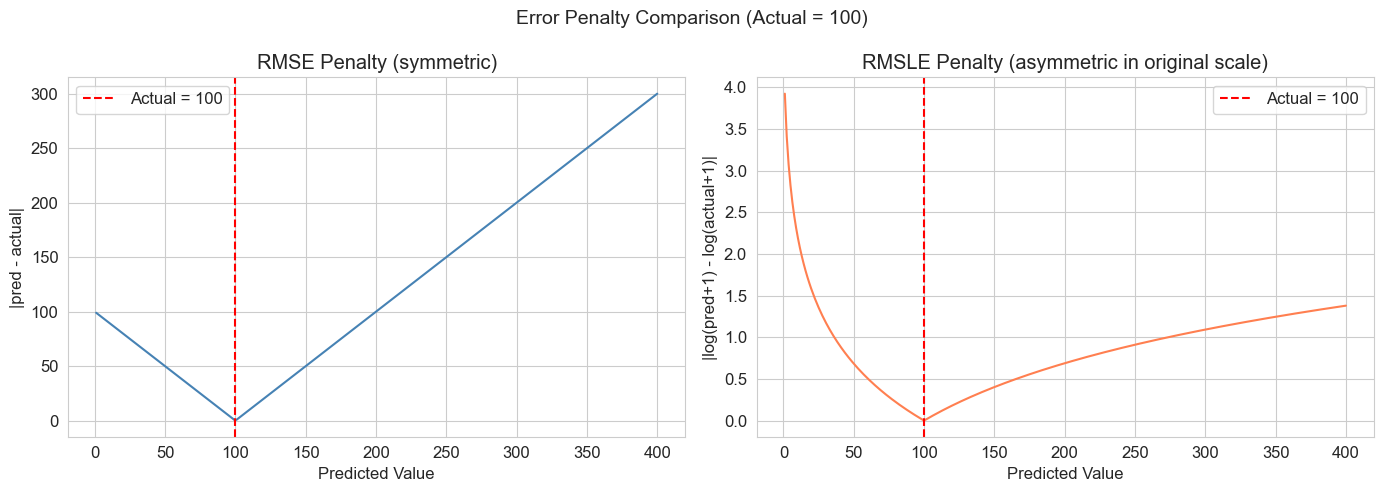

In [15]:
# Visual illustration: RMSLE vs RMSE penalty asymmetry
actual = 100
predictions = np.linspace(1, 400, 300)

rmse_vals  = np.abs(predictions - actual)
rmsle_vals = np.abs(np.log1p(predictions) - np.log1p(actual))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(predictions, rmse_vals, color='steelblue')
axes[0].axvline(actual, color='red', linestyle='--', label=f'Actual = {actual}')
axes[0].set_title('RMSE Penalty (symmetric)')
axes[0].set_xlabel('Predicted Value')
axes[0].set_ylabel('|pred - actual|')
axes[0].legend()

axes[1].plot(predictions, rmsle_vals, color='coral')
axes[1].axvline(actual, color='red', linestyle='--', label=f'Actual = {actual}')
axes[1].set_title('RMSLE Penalty (asymmetric in original scale)')
axes[1].set_xlabel('Predicted Value')
axes[1].set_ylabel('|log(pred+1) - log(actual+1)|')
axes[1].legend()

plt.suptitle(f'Error Penalty Comparison (Actual = {actual})', fontsize=14)
plt.tight_layout()
plt.savefig('rmsle_vs_rmse.png', dpi=150, bbox_inches='tight')
plt.show()

### Q11. Trade-offs between model simplicity and predictive power

**Answer Q11 – Bias-Variance Tradeoff:**

| Dimension | Simple Model (e.g., Linear Regression) | Complex Model (e.g., Degree-3 Poly, many features) |
|---|---|---|
| **Bias** | High – misses true patterns | Low – fits data closely |
| **Variance** | Low – stable across datasets | High – sensitive to noise |
| **Training error** | High | Very low |
| **Test/val error** | Moderate | May be very high (overfitting) |
| **Interpretability** | Easy – coefficient = effect | Hard – thousands of polynomial terms |
| **Computational cost** | Low | High |
| **Data requirements** | Low | High |

**Key principles:**
1. *Underfitting (high bias):* The model is too simple to capture the underlying pattern. Even training error is high.
2. *Overfitting (high variance):* The model memorizes training noise. Training error is low, but validation/test error is high.
3. *Sweet spot:* Regularized polynomial models (Ridge/Lasso) hit the optimal point by adding complexity while penalizing excessive parameter magnitude.
4. *Occam's Razor:* Among models with similar performance, prefer the simpler one for better generalization and interpretability.

### Q12. Why can't Linear Regression alone capture time-of-day effects effectively?

**Answer Q12:**

Linear Regression assumes the relationship between each feature and the target is **strictly linear and additive**:

$$\hat{y} = \beta_0 + \beta_1 \cdot \text{hour} + \beta_2 \cdot \text{temp} + \ldots$$

**Why this fails for hour:**

1. **Non-monotonic relationship:** Bike demand at hour=0 (midnight) ≈ 10 bikes, hour=8 (morning rush) ≈ 350 bikes, hour=13 (afternoon) ≈ 150 bikes, hour=17 (evening rush) ≈ 400 bikes, hour=23 (night) ≈ 30 bikes. This is a **bimodal, cyclic pattern** – no straight line can fit it.

2. **Cyclical nature is ignored:** Linear Regression treats hour as a continuous number (0–23). It cannot know that hour 23 and hour 0 are adjacent in time. Cyclic encodings (sin/cos) or one-hot encoding are needed.

3. **Interaction with other features:** The effect of hour *changes* based on workingday, season, weather. Linear Regression with a single `hour` coefficient cannot capture this – it applies the same slope regardless of context.

**Solutions used in this assignment:**
- **Cyclic encoding:** `hour_sin = sin(2π·hour/24)`, `hour_cos = cos(2π·hour/24)` – preserves cyclical structure.
- **Rush-hour flags:** `is_rush_am`, `is_rush_pm` – explicitly marks the bimodal peaks.
- **Polynomial/interaction terms:** Allow the model to learn nonlinear and conditional hour effects.
- **Tree-based models** (e.g., Random Forest, Gradient Boosting) would handle this even better by learning piecewise patterns.

---
## Final Submission: Generate submission.csv

In [16]:
# ── Retrain best model on FULL training data ──────────────────────────────────
X_full     = train_fe[ENG_FEATURES]
y_full     = train_fe[TARGET]
X_test_sub = test_fe[ENG_FEATURES]

# Refit best pipeline on full train set
poly_final   = PolynomialFeatures(degree=best_degree, include_bias=False)
scaler_final = StandardScaler()

X_full_poly = poly_final.fit_transform(scaler_final.fit_transform(X_full))
X_test_poly = poly_final.transform(scaler_final.transform(X_test_sub))

if 'Ridge' in best_mtype:
    final_model = Ridge(alpha=best_alpha)
elif 'Lasso' in best_mtype:
    final_model = Lasso(alpha=best_alpha, max_iter=5000)
else:
    final_model = LinearRegression()

final_model.fit(X_full_poly, y_full)
test_preds = np.maximum(final_model.predict(X_test_poly), 0)  # no negatives
test_preds = np.round(test_preds).astype(int)

# Build submission using the original datetime values and exact guideline columns
test_orig = pd.read_csv('bike_test.csv')
submission = pd.DataFrame({
    'datetime': test_orig['datetime'],
    'count_predicted': test_preds
})
submission.to_csv('submission.csv', index=False)
print('Submission columns:', submission.columns.tolist())
print('Submission shape:', submission.shape)
submission.head(10)

Submission columns: ['datetime', 'count_predicted']
Submission shape: (2613, 2)


,datetime,count_predicted
0,05-06-2012 5:00,0
1,19-03-2011 19:00,137
2,02-04-2012 6:00,77
3,13-07-2012 20:00,415
4,09-11-2011 19:00,303
5,10-03-2012 0:00,58
6,19-05-2011 13:00,144
7,01-05-2011 8:00,142
8,07-07-2012 8:00,199
9,07-05-2011 16:00,415
